# B1 From tables to sequences

In notebook A1, a **token** was an English word and a **sequence** was a sentence. Everything
from here on is the same machinery with two substitutions:

| | Notebook a1–a3 | This notebook |
|---|---|---|
| token | a word | **a life event** |
| sequence | a sentence | **a person** |
| vocabulary | 50,368 word pieces | **1,036 tokens** (one per concept) |

Our data is a [Synthea](https://github.com/synthetichealth/synthea) synthetic population:
116,441 simulated patients from Massachusetts, aged 35–65, with ten years of recorded
history each (no real patient data is involved).

**Keep that in mind: everything we recover today is a property of the synthetic data.**

## Setup

> The raw dump is 19 GB, so you are not downloading it.
> `scripts/build_events.py` compresses it to 58 MB and `scripts/build_workshop_data.py` cuts a **50,000-patient** extract of about 10 MB, which is what lives in the repository.
> I will upload the data-generation scripts after the workshop.

**Today's data:**

1. 50,000 synthetic patients, split **40,000 train / 10,000 test** (the `split` column in
   `cohort.parquet`). The 10,000 test patients were kept out of the model's
   pretraining, so they are the only honest place to measure anything.
2. Four source tables from the simulator:

   | table | what it records |
   |---|---|
   | `conditions` | diagnoses and findings, clinical *and* social: `Stress`, `Unemployed`, `Housing unsatisfactory` |
   | `medications` | prescriptions, at the level of drug, dose and form |
   | `procedures` | what was done at a visit: screenings, assessments, dental work, dialysis |
   | `immunizations` | vaccines |

3. Five files, all in `data/derived/workshop/`:

   | file | what is in it |
   |---|---|
   | `raw-sample.parquet` | dated timelines for 500 patients, one row per event, before *and* after the index date |
   | `sequences.parquet` | the full model input for all 50,000: background tokens, event tokens, days before the index date |
   | `cohort.parquet` | one row per patient: split, label, background attributes, event count |
   | `vocabulary.csv` | the 1,036 tokens with their corpus frequencies |
   | `severe-codes.csv` | the outcome definition: 38 codes in, 7 deliberately out |

The cell below finds those files in the repository if you cloned it, and downloads them from
the Hugging Face Hub if you did not.

In [26]:
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)

DATA_REPO = "carlomarxx/synthea-workshop-data"


def resolve(local_path, repo_id, repo_type="dataset"):
    """Prefer the copy in this repository; fall back to the Hub if it is not here."""
    if pathlib.Path(local_path).exists():
        return str(local_path), "already in this repository"
    from huggingface_hub import snapshot_download

    return snapshot_download(repo_id, repo_type=repo_type), f"downloaded from {repo_id}"


DATA, data_source = resolve("../data/derived/workshop", DATA_REPO)
print(f"workshop data: {DATA}\n               ({data_source})")

workshop data: ../data/derived/workshop
               (already in this repository)


## 1. Raw data

`raw-sample.parquet` holds the complete timelines of 500 patients: one row per recorded event.

**Sources:** the `conditions`, `medications`, `procedures` and `immunizations` tables.

In [27]:
raw = pd.read_parquet(f"{DATA}/raw-sample.parquet")
print(f"{len(raw):,} events for {raw.patient_id.nunique()} patients")
raw.head(10)

98,999 events for 500 patients


,patient_id,date,description,source
0,139,1982-05-25,Housing unsatisfactory (finding),conditions
1,139,1982-05-25,Educated to high school level (finding),conditions
2,139,1982-05-25,Transport problem (finding),conditions
3,139,1983-05-31,Lack of access to transportation (finding),conditions
4,139,1986-06-03,Refugee (person),conditions
5,139,2013-01-20,Localized primary osteoarthritis of the hand (disorder),conditions
6,139,2013-01-20,Naproxen sodium 220 MG Oral Tablet,medications
7,139,2013-03-19,Full-time employment (finding),conditions
8,139,2016-04-12,Medication review due (situation),conditions
9,139,2017-04-18,Gingivitis (disorder),conditions


In [28]:
# How much of each kind of event is there?
raw.source.value_counts().to_frame("events")

,events
source,
procedures,61001
conditions,17445
medications,14949
immunizations,5604


## 2. One person

Pick a patient and look at their life as the simulator recorded it. This is what we turn
into a sequence.

In [29]:
PATIENT = raw.patient_id.iloc[0]

person = raw[raw.patient_id == PATIENT].sort_values("date")
print(
    f"patient {PATIENT}: {len(person)} events "
    f"from {person.date.min():%Y-%m-%d} to {person.date.max():%Y-%m-%d}"
)
person.head(20)

patient 139: 149 events from 1982-05-25 to 2026-06-23


,patient_id,date,description,source
0,139,1982-05-25,Housing unsatisfactory (finding),conditions
1,139,1982-05-25,Educated to high school level (finding),conditions
2,139,1982-05-25,Transport problem (finding),conditions
3,139,1983-05-31,Lack of access to transportation (finding),conditions
4,139,1986-06-03,Refugee (person),conditions
5,139,2013-01-20,Localized primary osteoarthritis of the hand (disorder),conditions
6,139,2013-01-20,Naproxen sodium 220 MG Oral Tablet,medications
7,139,2013-03-19,Full-time employment (finding),conditions
8,139,2016-04-12,Medication review due (situation),conditions
17,139,2017-04-18,Influenza split virus trivalent PF,immunizations


### The index date

We are going to predict something about the **future**, so we must be strict about where
the past ends.

**Cut-off:** everything before **18 August 2021** is what the model sees. Everything in the
five years after it belongs to the outcome, and the model must never see it.

In [30]:
INDEX_DATE = pd.Timestamp("2021-08-18")
END_DATE = pd.Timestamp("2026-08-18")

history = person[person.date < INDEX_DATE]
future = person[(person.date >= INDEX_DATE) & (person.date <= END_DATE)]

print(f"history  {len(history):4d} events   (feature window)")
print(
    f"future   {len(future):4d} events   (outcome window -- the model never sees these)"
)

history   104 events   (feature window)
future     45 events   (outcome window -- the model never sees these)


## 3. Collapsing repeats

Some events repeat constantly: `Medication review due (situation)` fires at every routine
visit. A run of the same event back to back carries almost no information, and it eats the
sequence budget. We collapse **consecutive** duplicates: `A A A B B A` becomes `A B A`. This keeps the second `A`: the person went back, and that is worth knowing.

Over the whole corpus that rule removed 6.9% of rows: 26,747,307 events → **24,903,816**.

> This is a modelling decision, not data cleaning. life2vec did not collapse repeats; we do
> it here to keep the sequences short.

In [32]:
person.description.value_counts().head(8).to_frame("times recorded")

,times recorded
description,
Assessment of health and social care needs (procedure),11
Depression screening (procedure),10
Influenza split virus trivalent PF,10
Assessment of substance use (procedure),8
Assessment of anxiety (procedure),7
Dental consultation and report (procedure),6
Medication review due (situation),6
Oral health education (procedure),6


`build_events.py` already applied the rule before this extract was cut, so re-running it here
barely changes anything. The point is to see what the rule does, not to see it bite.

In [33]:
def collapse_consecutive(events: pd.DataFrame) -> pd.DataFrame:
    """Drop an event when it repeats the event immediately before it."""
    events = events.sort_values("date")
    repeat = events.description.eq(events.description.shift())
    return events[~repeat]


collapsed = collapse_consecutive(history)
print(
    f"this patient: {len(history)} events -> {len(collapsed)} after collapsing "
    f"consecutive repeats ({1 - len(collapsed) / len(history):.0%} removed)"
)

this patient: 104 events -> 103 after collapsing consecutive repeats (1% removed)


## 4. The vocabulary

Our model needs a vocabulary:

1. `ModernBERT` in A1–A3 split English into word pieces. Here one token is one *concept*: a
   diagnosis, a drug, a procedure, a vaccine, or one of a person's background attributes.
2. `vocabulary.csv` holds the finished list. It is precomputed, because building it means a
   pass over the full corpus.

**How the tokens were picked** -> over all **116,441 patients and 24.9 M events**, not just
the 50,000 patients shipped here:

1. Take the `description` field of every event: **1,161 distinct** strings.
2. Keep every description occurring **at least 30 times** → **985** event types.
3. The 176 rarer ones map to `[UNK]`. Together they are 0.008% of all events.
4. Add 46 background tokens and BERT's 5 special tokens → **1,036 tokens**.

The threshold is `MIN_FREQ` in `scripts/build_workshop_data.py`. Changing it renumbers every
token, so the tokenizer and the model both have to be rebuilt.

In [34]:
vocabulary = pd.read_csv(f"{DATA}/vocabulary.csv")
print(vocabulary.kind.value_counts().to_string())
vocabulary.groupby("kind").head(3)

kind
event         985
background     46
special         5


,token_id,token,kind,source,frequency,is_severe_outcome
0,0,[PAD],special,NaN,0,False
1,1,[UNK],special,NaN,0,False
2,2,[CLS],special,NaN,0,False
5,5,AGE_30_34,background,NaN,0,False
6,6,AGE_35_39,background,NaN,0,False
7,7,AGE_40_44,background,NaN,0,False
51,51,Assessment of health and social care needs (procedure),event,procedures,1182590,False
52,52,Depression screening (procedure),event,procedures,985621,False
53,53,Influenza split virus trivalent PF,event,immunizations,916201,False


**Token types:**

1. **Special tokens** (5) are BERT's own: `[PAD]`, `[UNK]`, `[CLS]`, `[SEP]`, `[MASK]`.
2. **Event tokens** (985) are the event types occurring at least 30 times.
3. **Background tokens** (46) are a person's static attributes: age band, sex, race,
   ethnicity, marital status and income bin (25 of them). They go at the front of the
   sequence as tokens, following
   [life2vec](https://doi.org/10.1038/s43588-023-00573-5), rather than being bolted on as
   separate features downstream.

In [35]:
vocabulary[vocabulary.kind == "background"].token.tolist()

['AGE_30_34',
 'AGE_35_39',
 'AGE_40_44',
 'AGE_45_49',
 'AGE_50_54',
 'AGE_55_59',
 'ETH_hispanic',
 'ETH_nonhispanic',
 'INCOME_B01',
 'INCOME_B02',
 'INCOME_B03',
 'INCOME_B04',
 'INCOME_B05',
 'INCOME_B06',
 'INCOME_B07',
 'INCOME_B08',
 'INCOME_B09',
 'INCOME_B10',
 'INCOME_B11',
 'INCOME_B12',
 'INCOME_B13',
 'INCOME_B14',
 'INCOME_B15',
 'INCOME_B16',
 'INCOME_B17',
 'INCOME_B18',
 'INCOME_B19',
 'INCOME_B20',
 'INCOME_B21',
 'INCOME_B22',
 'INCOME_B23',
 'INCOME_B24',
 'INCOME_B25',
 'MARITAL_D',
 'MARITAL_M',
 'MARITAL_NA',
 'MARITAL_S',
 'MARITAL_W',
 'RACE_asian',
 'RACE_black',
 'RACE_hawaiian',
 'RACE_native',
 'RACE_other',
 'RACE_white',
 'SEX_F',
 'SEX_M']

In [36]:
# The most frequent events in the whole corpus.
vocabulary[vocabulary.kind == "event"].nlargest(20, "frequency")[
    ["token", "source", "frequency"]
]

,token,source,frequency
51,Assessment of health and social care needs (procedure),procedures,1182590
52,Depression screening (procedure),procedures,985621
53,Influenza split virus trivalent PF,immunizations,916201
54,Assessment of substance use (procedure),procedures,730271
55,Medication review due (situation),conditions,661551
56,Medication reconciliation (procedure),procedures,625747
57,Dental consultation and report (procedure),procedures,602017
58,Patient referral for dental care (procedure),procedures,599168
59,Assessment of anxiety (procedure),procedures,590480
60,Oral health education (procedure),procedures,583308


**The top of it is the health system, not the patient.** Assessments, screenings, reviews
and reconciliations fill most of the first fifteen rows, led by `Assessment of health and
social care needs (procedure)` at 1.18 M occurrences. Those codes record that somebody
*looked*. Exercise 2 comes back to what that does to a prediction target.

**Social determinants of health are ordinary tokens here.** `Stress (finding)` (350,829),
`Full-time employment (finding)` (329,959), `Part-time employment` (200,298), `Limited
social contact` (121,315), `Social isolation` (121,122), `Victim of intimate partner abuse`
(84,258) and `Unemployed` (52,917) all sit inside the 90 most frequent of the 985 event
types. A model trained here is learning more than medicine, which is what makes this a
social-science exercise.

## 5. Events → token ids

The mapping is a plain dictionary lookup. Nothing is *learned* here, which is the difference
between tokenising a life and tokenising English: the vocabulary is already finite and every
event is an atom, so there are no word pieces to find.

In [37]:
token_id = dict(zip(vocabulary.token, vocabulary.token_id))
UNK = token_id["[UNK]"]

sequence = [token_id.get(d, UNK) for d in collapsed.description]

pd.DataFrame(
    {
        "date": collapsed.date.dt.date.values,
        "event": collapsed.description.values,
        "token_id": sequence,
    }
).head(15)

,date,event,token_id
0,1982-05-25,Housing unsatisfactory (finding),208
1,1982-05-25,Educated to high school level (finding),171
2,1982-05-25,Transport problem (finding),242
3,1983-05-31,Lack of access to transportation (finding),241
4,1986-06-03,Refugee (person),332
5,2013-01-20,Localized primary osteoarthritis of the hand (disorder),442
6,2013-01-20,Naproxen sodium 220 MG Oral Tablet,177
7,2013-03-19,Full-time employment (finding),75
8,2016-04-12,Medication review due (situation),55
9,2017-04-18,Depression screening (procedure),52


A human life on the left, a list of integers on the right. That is all the model gets.

## 6. Assembling the full sequence

The input interleaves background and events, with BERT's separators. Each position carries
two extra numbers. The values below are the patient printed live two cells further down, so
the table and that output should agree:

| position | 0 | 1 … 6 | 7 | 8 | 9 | … | last |
|---|---|---|---|---|---|---|---|
| **token** | `[CLS]` | `AGE_55_59` `SEX_M` `RACE_white` `ETH_nonhispanic` `MARITAL_M` `INCOME_B06` | `[SEP]` | `Housing unsatisfactory` | `Transport problem` | … | `[SEP]` |
| **days before index** | 0 | 0 | 0 | 14,330 | 14,330 | … | 0 |
| **age** | 57.4 | 57.4 | 57.4 | 18.1 | 18.1 | … | 57.4 |

Background tokens and separators are timeless, so they are given the age at the index date
and zero days.

Every position the model sees is the sum of four things (`scripts/event_bert.py`):

- the **token embedding** -> what happened
- BERT's learned **absolute position** -> first, second, third: rank order only
- **Time2Vec(age)** -> how old the person was, the *life clock*
- **Time2Vec(days before the index date)** -> how long before the cut-off, the *recency clock*

`sequences.parquet` stores `days_before_index`; age is derived from it as
`age_at_index - days / 365.25`, with `age_at_index` coming from `cohort.parquet`. Rank order
alone cannot tell three days from three years, which is why both clocks are there: life2vec
counted days since a fixed date, BEHRT encodes age. Notebook b2 uses them.

### The precomputed sequences

Turning 24.9 M rows into one sequence per patient is another full pass over the corpus, so
that is precomputed as well.

In [38]:
sequences = pd.read_parquet(f"{DATA}/sequences.parquet")
cohort = pd.read_parquet(f"{DATA}/cohort.parquet")

print(f"{len(sequences):,} sequences")
print(
    cohort.groupby("split")
    .agg(
        patients=("patient_id", "size"),
        eligible=("eligible", "sum"),
        positives=("severe_within_5y", "sum"),
    )
    .to_string()
)
sequences.head(3)

49,998 sequences
       patients  eligible  positives
split                               
test      10000      7965        525
train     40000     31966       2126


,patient_id,background,tokens,days_before_index,length
0,1,"[5, 49, 48, 12, 39, 30]","[162, 161, 160, 144, 159, 152, 155, 156, 153, 154, 94, 7...","[1651, 1651, 1651, 1651, 1651, 1651, 1651, 1651, 1651, 1...",119
1,2,"[7, 50, 46, 12, 38, 36]","[171, 55, 107, 82, 374, 422, 203, 71, 51, 59, 54, 68, 53...","[8370, 3603, 3603, 2504, 1769, 1769, 1769, 1405, 1405, 1...",44
2,3,"[9, 50, 48, 12, 39, 17]","[208, 171, 309, 169, 310, 305, 55, 75, 105, 71, 101, 51,...","[11675, 11675, 11489, 11408, 11364, 8272, 5809, 5809, 56...",93


In [39]:
name_of = dict(zip(vocabulary.token_id, vocabulary.token))
age_of = dict(zip(cohort.patient_id, cohort.age_at_index))

row = sequences[sequences.patient_id == PATIENT].iloc[0]
base_age = float(age_of[PATIENT])

print("background:", [name_of[t] for t in row.background])
print(f"age at the index date: {base_age:.1f}")
print()
print("first 8 events:")
for tok, days in list(zip(row.tokens, row.days_before_index))[:8]:
    print(
        f"  {days:5d} days before index   age {base_age - days / 365.25:5.1f}   {name_of[tok]}"
    )

background: ['AGE_55_59', 'SEX_M', 'RACE_white', 'ETH_nonhispanic', 'MARITAL_M', 'INCOME_B06']
age at the index date: 57.4

first 8 events:
  14330 days before index   age  18.1   Housing unsatisfactory (finding)
  14330 days before index   age  18.1   Educated to high school level (finding)
  14330 days before index   age  18.1   Transport problem (finding)
  13959 days before index   age  19.2   Lack of access to transportation (finding)
  12860 days before index   age  22.2   Refugee (person)
   3132 days before index   age  48.8   Localized  primary osteoarthritis of the hand (disorder)
   3132 days before index   age  48.8   Naproxen sodium 220 MG Oral Tablet
   3074 days before index   age  49.0   Full-time employment (finding)


## 7. How long is a life?

1. BERT needs a fixed maximum length, and the life-sequence BERT we are about to use is set
   up for **128 positions**, kept small so everything here runs in seconds.
2. `[CLS]` + 6 background + 2 `[SEP]` leaves **119** slots for events.
3. Anyone with a longer history is truncated to their most recent 119: the earlier events go.

Careful here: the `length` column in `sequences.parquet` is the length *after* truncation,
so it can never exceed 119. To see how much history people really have, use
`n_events_before_index` from `cohort.parquet`, which counts everything.

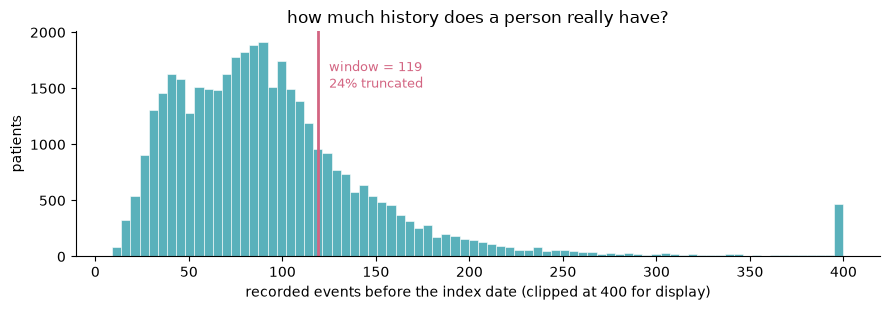

median 85 events, 90th percentile 159, max 1,966


In [40]:
eligible = cohort[cohort.eligible].merge(sequences, on="patient_id")
true_length = eligible.n_events_before_index

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(
    true_length.clip(upper=400),
    bins=80,
    color="#5AB1BB",
    edgecolor="white",
    linewidth=0.4,
)
ax.axvline(119, color="#D36582", lw=2)
ax.annotate(
    f"window = 119\n{(true_length > 119).mean():.0%} truncated",
    (119, ax.get_ylim()[1] * 0.75),
    xytext=(8, 0),
    textcoords="offset points",
    fontsize=9,
    color="#D36582",
)
ax.set_xlabel("recorded events before the index date (clipped at 400 for display)")
ax.set_ylabel("patients")
ax.set_title("how much history does a person really have?")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

print(
    f"median {true_length.median():.0f} events, "
    f"90th percentile {true_length.quantile(0.9):.0f}, max {true_length.max():,}"
)

### ✏️ Exercise 1: choose the window

Try 32, 64, 119 and 256. For each, work out what fraction of patients is fully covered and
what fraction of *all recorded events* survives.

**Question**: which patients get truncated?

<details>
<summary>
<b>Hint</b>
</summary>

You can use the background tokens to see how patients of different ages, incomes or
ethnicities get truncated.
</details>

In [41]:
for window in [32, 64, 119, 256, 512]:
    covered = (true_length <= window).mean()
    kept = np.minimum(true_length, window).sum() / true_length.sum()

    # Your turn: is the outcome rate different for the patients this window truncates?
    # Use eligible.severe_within_5y together with the `truncated` mask.
    truncated = true_length > window
    truncated_rate = ...  # <- your code: outcome rate among truncated patients
    intact_rate = ...  # <- your code: outcome rate among the rest

    print(
        f"window {window:4d}: {covered:5.1%} of patients fully covered, "
        f"{kept:5.1%} of events kept"
    )

window   32:  7.1% of patients fully covered, 32.0% of events kept
window   64: 31.8% of patients fully covered, 58.3% of events kept
window  119: 76.5% of patients fully covered, 83.4% of events kept
window  256: 97.5% of patients fully covered, 94.8% of events kept
window  512: 99.3% of patients fully covered, 98.2% of events kept


### ✏️ Exercise 2: the outcomes for the finetuning

We are going to predict the onset of a **severe disease** (predefined by me).

In [42]:
severe = pd.read_csv(f"{DATA}/severe-codes.csv")
print(severe[severe.in_outcome].groupby("group").size().to_string())
severe[severe.in_outcome].head(10)[["code", "group", "patients_ever"]]

group
Cancer                 13
Cardiovascular          9
Neurodegenerative       1
Renal failure           5
Respiratory failure     4
Sepsis / shock          6


,code,group,patients_ever
0,Myocardial infarction (disorder),Cardiovascular,1861
1,Acute ST segment elevation myocardial infarction (disorder),Cardiovascular,940
2,Acute non-ST segment elevation myocardial infarction (di...,Cardiovascular,1309
3,Preinfarction syndrome (disorder),Cardiovascular,123
4,Cerebrovascular accident (disorder),Cardiovascular,530
5,Chronic congestive heart failure (disorder),Cardiovascular,1996
6,Heart failure (disorder),Cardiovascular,83
7,Acute pulmonary embolism (disorder),Cardiovascular,669
8,Acute deep venous thrombosis (disorder),Cardiovascular,717
9,Malignant neoplasm of breast (disorder),Cancer,1820


In [18]:
# The codes deliberately LEFT OUT, and why.
severe[~severe.in_outcome][["code", "patients_ever", "note"]]

,code,patients_ever,note
38,Suspected lung cancer (situation),533,"work-up artefact -- records that someone looked, not wha..."
39,Suspected prostate cancer (situation),303,work-up artefact
40,Awaiting transplantation of kidney (situation),2366,"administrative status, downstream of end-stage renal dis..."
41,Died in hospice (finding),514,a death marker; including it would leak the outcome
42,History of myocardial infarction (situation),2365,"history code -- refers to the past, not a new event"
43,Atrial fibrillation (disorder),329,significant but not catastrophic; keeps the composite un...
44,Chronic kidney disease stage 3 (disorder),4302,not yet organ failure; deliberately retained as a PREDICTOR


`Suspected lung cancer (situation)` is not lung cancer: it records that somebody *looked*.
Including it would have produced a spectacular and meaningless result, because the code only
exists once a clinician already suspects the answer. Hence the rule:

> **A code that records the health system looking for a disease is not the disease.**

**Your turn.** Name one code you would add to the outcome, and one you would remove. Write a
sentence of justification for each. We will take a few of these aloud.

In [43]:
# Browse the full event vocabulary to make your case.
events = vocabulary[vocabulary.kind == "event"]
events[
    events.token.str.contains(
        "cancer|neoplasm|failure|infarction", case=False, regex=True
    )
][["token", "frequency"]].head(20)

,token,frequency
453,Heart failure education (procedure),2525
466,History of myocardial infarction (situation),2365
493,Chronic congestive heart failure (disorder),1996
501,Myocardial infarction (disorder),1861
506,Malignant neoplasm of breast (disorder),1820
551,Acute non-ST segment elevation myocardial infarction (di...,1309
592,Acute ST segment elevation myocardial infarction (disorder),940
597,Acute respiratory failure (disorder),890
652,Malignant neoplasm of colon (disorder),632
654,Overlapping malignant neoplasm of colon (disorder),616


## What we built

- A person is now a **sequence of tokens**: static background, then events in order.
- Every event position carries two clocks: the **age** at which it happened and the **days
  before the index date**.
- The vocabulary is 1,036 tokens; the 119-event window is a decision with consequences.
- The outcome is an explicit, arguable list of 38 codes, with 7 deliberate exclusions.

**Next:** notebook b2 pretrains a transformer on these sequences by masking events and asking it
to guess what belongs in the gap.